In [1]:
#------使用XGBoost模型-透射光谱-使用光谱预处理方法------#
#------储存路径代号：XGB_01------#

In [2]:
import os
import sys
from pathlib import Path
project_root = Path('/home/liudaolong/Project/07-Honey')
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
from utils.train_log import EvaluationMetricsLogger
from utils import datalodaer,model_trainer,preprocess,utils,ploter

import numpy as np
from datetime import datetime


# 设置全局字体为 "Times New Roman"
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 9         # 设置全局字体大小
plt.rcParams['axes.unicode_minus'] = False  # 设置支持负号显示
plt.rcParams['svg.fonttype'] = 'none'

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

series_path = '02-XGB-TS-Preprocessing'

In [3]:
spectra_path = project_root / 'data/spectra/Spectra_TS_wavelength.csv'
labels_file = project_root / 'data/labels'
logger = EvaluationMetricsLogger()

加载现有日志文件: ../results/model_evaluation/evaluation_metrics_log.csv，包含 270 条记录


In [4]:
# 定义预处理方法字典
preprocess_methods = {
    "Raw":          preprocess.DummyTransformer(),  # 原始数据
    "Detrend":      preprocess.Detrend(type='linear'), # 线性基线校正
    "SNV":          preprocess.SNV(),               # 标准正态变量变换
    "MSC":          preprocess.MSC(),               # 多元散射校正
    "SG_1":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=1), # 一阶导
    "SG_2":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=2)  # 二阶导
}

[I 2026-01-22 15:26:56,110] A new study created in memory with name: xgb_optuna_tuning


NO.1 [正在训练: PH | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 79
  最优参数: {'learning_rate': 0.035430636364492604, 'max_depth': 3, 'min_child_weight': 6.289012432907541, 'subsample': 0.5633132822088522, 'colsample_bytree': 0.3239915661558506, 'reg_lambda': 0.02090231748227284, 'reg_alpha': 0.0019409859401292126, 'gamma': 0.00015457845581939118}
  最优验证集 RMSE: 0.08675608038902283
  对应 best_iteration: 411
实验记录已保存: PH-02-XGB-TS-Preprocessing
训练集 R²: 0.9591, 验证集 R²: 0.5169, 测试集 R²: 0.5668



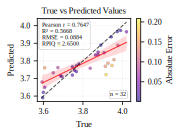

NO.2 [正在训练: PH | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 88
  最优参数: {'learning_rate': 0.006484516633571282, 'max_depth': 4, 'min_child_weight': 3.629937210482545, 'subsample': 0.9480413945208169, 'colsample_bytree': 0.6915022838021416, 'reg_lambda': 0.0020473459754815114, 'reg_alpha': 0.0018715269249487498, 'gamma': 0.004081001916367851}
  最优验证集 RMSE: 0.08539262413978577
  对应 best_iteration: 725
实验记录已保存: PH-02-XGB-TS-Preprocessing
训练集 R²: 0.9662, 验证集 R²: 0.5319, 测试集 R²: 0.5869



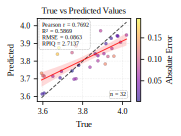

NO.3 [正在训练: PH | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 87
  最优参数: {'learning_rate': 0.019261067721447235, 'max_depth': 4, 'min_child_weight': 3.7928853490881744, 'subsample': 0.8415653675289613, 'colsample_bytree': 0.39384802991364776, 'reg_lambda': 0.002298927725088801, 'reg_alpha': 0.0013729152166917673, 'gamma': 0.0051520601205988}
  最优验证集 RMSE: 0.0859590396285057
  对应 best_iteration: 839
实验记录已保存: PH-02-XGB-TS-Preprocessing
训练集 R²: 0.9565, 验证集 R²: 0.5257, 测试集 R²: 0.5500



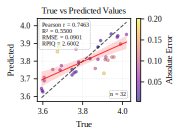

NO.4 [正在训练: PH | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 79
  最优参数: {'learning_rate': 0.00914826997172085, 'max_depth': 5, 'min_child_weight': 4.01241276379314, 'subsample': 0.9422407783794076, 'colsample_bytree': 0.39566153191433767, 'reg_lambda': 0.007956489738007708, 'reg_alpha': 0.0040947420767752435, 'gamma': 0.00016217958452192927}
  最优验证集 RMSE: 0.08788283914327621
  对应 best_iteration: 1097
实验记录已保存: PH-02-XGB-TS-Preprocessing
训练集 R²: 0.9972, 验证集 R²: 0.5042, 测试集 R²: 0.6018



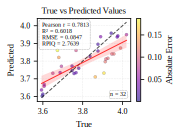

NO.5 [正在训练: PH | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 88
  最优参数: {'learning_rate': 0.07336421052225015, 'max_depth': 8, 'min_child_weight': 2.6438780551384093, 'subsample': 0.7997154369208022, 'colsample_bytree': 0.959204106775199, 'reg_lambda': 4.175690066497971, 'reg_alpha': 0.022696822349515495, 'gamma': 0.004082367821195315}
  最优验证集 RMSE: 0.07118463516235352
  对应 best_iteration: 148
实验记录已保存: PH-02-XGB-TS-Preprocessing
训练集 R²: 0.9771, 验证集 R²: 0.6747, 测试集 R²: 0.6855



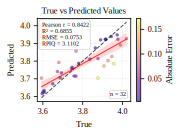

NO.6 [正在训练: PH | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 77
  最优参数: {'learning_rate': 0.03340822256909593, 'max_depth': 7, 'min_child_weight': 6.96643396728284, 'subsample': 0.6787262054426577, 'colsample_bytree': 0.8615782638749551, 'reg_lambda': 0.028383084375704866, 'reg_alpha': 0.06730180894304715, 'gamma': 0.0034041617639068867}
  最优验证集 RMSE: 0.06270821392536163
  对应 best_iteration: 178
实验记录已保存: PH-02-XGB-TS-Preprocessing
训练集 R²: 0.9759, 验证集 R²: 0.7476, 测试集 R²: 0.6965



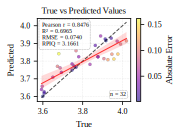

NO.7 [正在训练: GLU | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 93
  最优参数: {'learning_rate': 0.045933445752505395, 'max_depth': 7, 'min_child_weight': 6.459430784340592, 'subsample': 0.72675377352179, 'colsample_bytree': 0.38393586607966956, 'reg_lambda': 1.3268387007848792, 'reg_alpha': 0.005080254287043772, 'gamma': 0.005761729473503887}
  最优验证集 RMSE: 1.514445185661316
  对应 best_iteration: 1090
实验记录已保存: GLU-02-XGB-TS-Preprocessing
训练集 R²: 0.9997, 验证集 R²: 0.7602, 测试集 R²: 0.6039



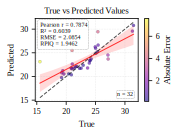

NO.8 [正在训练: GLU | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 52
  最优参数: {'learning_rate': 0.07578782520308044, 'max_depth': 8, 'min_child_weight': 9.613351126663368, 'subsample': 0.5634114272244484, 'colsample_bytree': 0.3534102690915338, 'reg_lambda': 31.160662026566563, 'reg_alpha': 0.05922105095696734, 'gamma': 0.7591064134128576}
  最优验证集 RMSE: 1.517451524734497
  对应 best_iteration: 132
实验记录已保存: GLU-02-XGB-TS-Preprocessing
训练集 R²: 0.8783, 验证集 R²: 0.7593, 测试集 R²: 0.6668



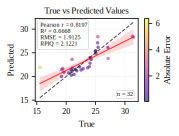

NO.9 [正在训练: GLU | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 95
  最优参数: {'learning_rate': 0.011920618324440519, 'max_depth': 7, 'min_child_weight': 9.592139841106142, 'subsample': 0.5553272973827179, 'colsample_bytree': 0.9547364214461679, 'reg_lambda': 0.2686060112656232, 'reg_alpha': 0.0036467168118140617, 'gamma': 4.675409114141951}
  最优验证集 RMSE: 1.6015543937683105
  对应 best_iteration: 580
实验记录已保存: GLU-02-XGB-TS-Preprocessing
训练集 R²: 0.9280, 验证集 R²: 0.7319, 测试集 R²: 0.6509



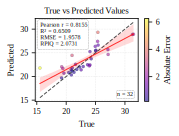

NO.10 [正在训练: GLU | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 99
  最优参数: {'learning_rate': 0.03312149582704105, 'max_depth': 2, 'min_child_weight': 6.148921837076857, 'subsample': 0.5098053886236559, 'colsample_bytree': 0.8747533474010611, 'reg_lambda': 0.5236992943719394, 'reg_alpha': 0.0020276566380732493, 'gamma': 0.4749382916653676}
  最优验证集 RMSE: 1.5845558643341064
  对应 best_iteration: 105
实验记录已保存: GLU-02-XGB-TS-Preprocessing
训练集 R²: 0.8955, 验证集 R²: 0.7375, 测试集 R²: 0.6503



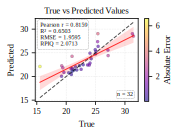

NO.11 [正在训练: GLU | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 59
  最优参数: {'learning_rate': 0.007411343454578657, 'max_depth': 5, 'min_child_weight': 9.668973864763647, 'subsample': 0.8606572109464836, 'colsample_bytree': 0.4386539803360434, 'reg_lambda': 0.002578106068172858, 'reg_alpha': 0.14211292765208372, 'gamma': 0.7215485490479956}
  最优验证集 RMSE: 1.2532416582107544
  对应 best_iteration: 1354
实验记录已保存: GLU-02-XGB-TS-Preprocessing
训练集 R²: 0.9913, 验证集 R²: 0.8358, 测试集 R²: 0.6357



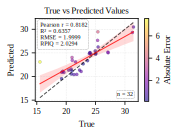

NO.12 [正在训练: GLU | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 89
  最优参数: {'learning_rate': 0.01021275968722207, 'max_depth': 3, 'min_child_weight': 8.778410772290744, 'subsample': 0.9309833840566635, 'colsample_bytree': 0.8364428667485162, 'reg_lambda': 0.17210015458875547, 'reg_alpha': 0.002420712866527733, 'gamma': 2.076472132993157}
  最优验证集 RMSE: 1.3686915636062622
  对应 best_iteration: 780
实验记录已保存: GLU-02-XGB-TS-Preprocessing
训练集 R²: 0.9845, 验证集 R²: 0.8042, 测试集 R²: 0.7278



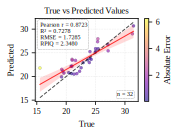

NO.13 [正在训练: 5-HMF | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 92
  最优参数: {'learning_rate': 0.0034863328662911846, 'max_depth': 3, 'min_child_weight': 1.707776024959487, 'subsample': 0.7547660635403567, 'colsample_bytree': 0.3027299769490338, 'reg_lambda': 0.010223318156736255, 'reg_alpha': 4.5945988515726635, 'gamma': 2.427791904604959}
  最优验证集 RMSE: 89.14460754394531
  对应 best_iteration: 4998
实验记录已保存: 5-HMF-02-XGB-TS-Preprocessing
训练集 R²: 0.9994, 验证集 R²: 0.6708, 测试集 R²: 0.7646



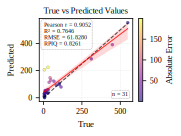

NO.14 [正在训练: 5-HMF | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 68
  最优参数: {'learning_rate': 0.02560629893752297, 'max_depth': 6, 'min_child_weight': 2.000812593811015, 'subsample': 0.9968910262867894, 'colsample_bytree': 0.5820150960400425, 'reg_lambda': 0.024977879866203596, 'reg_alpha': 0.2820735611604545, 'gamma': 2.9442401966652385}
  最优验证集 RMSE: 69.95453643798828
  对应 best_iteration: 174
实验记录已保存: 5-HMF-02-XGB-TS-Preprocessing
训练集 R²: 0.9974, 验证集 R²: 0.7973, 测试集 R²: 0.8329



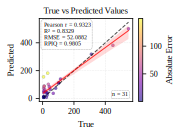

NO.15 [正在训练: 5-HMF | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 69
  最优参数: {'learning_rate': 0.06816458856822549, 'max_depth': 7, 'min_child_weight': 2.0863363907286163, 'subsample': 0.6044163119690891, 'colsample_bytree': 0.8107705163157196, 'reg_lambda': 61.462028023204184, 'reg_alpha': 0.39676739781733655, 'gamma': 1.3966694418956358}
  最优验证集 RMSE: 79.89742279052734
  对应 best_iteration: 4998
实验记录已保存: 5-HMF-02-XGB-TS-Preprocessing
训练集 R²: 0.9998, 验证集 R²: 0.7355, 测试集 R²: 0.7668



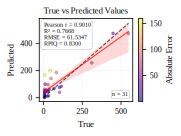

NO.16 [正在训练: 5-HMF | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 99
  最优参数: {'learning_rate': 0.06809838116725966, 'max_depth': 8, 'min_child_weight': 1.8526908233052992, 'subsample': 0.9691761663417837, 'colsample_bytree': 0.9457022565007909, 'reg_lambda': 0.01493060714181019, 'reg_alpha': 0.001999961641933403, 'gamma': 1.9520263422018806}
  最优验证集 RMSE: 58.930816650390625
  对应 best_iteration: 262
实验记录已保存: 5-HMF-02-XGB-TS-Preprocessing
训练集 R²: 1.0000, 验证集 R²: 0.8561, 测试集 R²: 0.4840



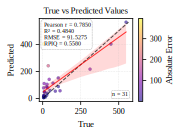

NO.17 [正在训练: 5-HMF | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 93
  最优参数: {'learning_rate': 0.057093373989569124, 'max_depth': 3, 'min_child_weight': 7.522900525007742, 'subsample': 0.6348741459220755, 'colsample_bytree': 0.6654008353950918, 'reg_lambda': 0.054217881362068565, 'reg_alpha': 0.040195164146598704, 'gamma': 2.953083188977465}
  最优验证集 RMSE: 46.84376907348633
  对应 best_iteration: 703
实验记录已保存: 5-HMF-02-XGB-TS-Preprocessing
训练集 R²: 0.9999, 验证集 R²: 0.9091, 测试集 R²: 0.8765



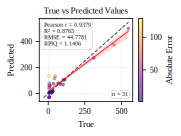

NO.18 [正在训练: 5-HMF | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 61
  最优参数: {'learning_rate': 0.08433131980861482, 'max_depth': 8, 'min_child_weight': 9.363961208972372, 'subsample': 0.5458150085996595, 'colsample_bytree': 0.4570260594313974, 'reg_lambda': 2.1731146804343098, 'reg_alpha': 0.4823010462067153, 'gamma': 2.2986793938174466}
  最优验证集 RMSE: 46.83804702758789
  对应 best_iteration: 622
实验记录已保存: 5-HMF-02-XGB-TS-Preprocessing
训练集 R²: 0.9997, 验证集 R²: 0.9091, 测试集 R²: 0.9409



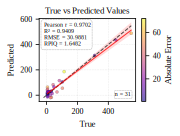

NO.19 [正在训练: Water | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 89
  最优参数: {'learning_rate': 0.051431184079809386, 'max_depth': 5, 'min_child_weight': 6.691663347200056, 'subsample': 0.8090097115841914, 'colsample_bytree': 0.30059998585181985, 'reg_lambda': 0.19600851905398736, 'reg_alpha': 0.049777738262833576, 'gamma': 0.134042108993413}
  最优验证集 RMSE: 0.6959530115127563
  对应 best_iteration: 619
实验记录已保存: Water-02-XGB-TS-Preprocessing
训练集 R²: 0.9981, 验证集 R²: 0.9688, 测试集 R²: 0.9689



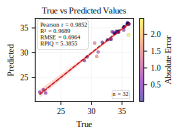

NO.20 [正在训练: Water | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 73
  最优参数: {'learning_rate': 0.06004957971530004, 'max_depth': 8, 'min_child_weight': 8.917477971480366, 'subsample': 0.5649043075631875, 'colsample_bytree': 0.9942149669771594, 'reg_lambda': 0.017822939977949863, 'reg_alpha': 0.17781846625752962, 'gamma': 0.19313088539063772}
  最优验证集 RMSE: 0.7223533987998962
  对应 best_iteration: 122
实验记录已保存: Water-02-XGB-TS-Preprocessing
训练集 R²: 0.9948, 验证集 R²: 0.9664, 测试集 R²: 0.9740



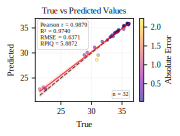

NO.21 [正在训练: Water | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 96
  最优参数: {'learning_rate': 0.006499694065405654, 'max_depth': 7, 'min_child_weight': 4.103483223130406, 'subsample': 0.500083756476282, 'colsample_bytree': 0.4395239150939306, 'reg_lambda': 3.487103642041396, 'reg_alpha': 0.4471612510380064, 'gamma': 0.31026924149260765}
  最优验证集 RMSE: 0.4886862635612488
  对应 best_iteration: 2161
实验记录已保存: Water-02-XGB-TS-Preprocessing
训练集 R²: 0.9957, 验证集 R²: 0.9846, 测试集 R²: 0.9744



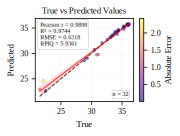

NO.22 [正在训练: Water | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 51
  最优参数: {'learning_rate': 0.0015870055115278306, 'max_depth': 6, 'min_child_weight': 5.232550944825982, 'subsample': 0.536009132028527, 'colsample_bytree': 0.6659413761682123, 'reg_lambda': 0.03210784618682585, 'reg_alpha': 0.014803564923072183, 'gamma': 0.25402147932488145}
  最优验证集 RMSE: 0.5275942087173462
  对应 best_iteration: 4310
实验记录已保存: Water-02-XGB-TS-Preprocessing
训练集 R²: 0.9964, 验证集 R²: 0.9821, 测试集 R²: 0.9828



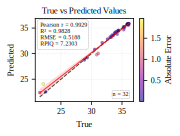

NO.23 [正在训练: Water | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 85
  最优参数: {'learning_rate': 0.09599079012582168, 'max_depth': 4, 'min_child_weight': 7.652246903196491, 'subsample': 0.686043885553277, 'colsample_bytree': 0.6365964256490542, 'reg_lambda': 0.004646991617378454, 'reg_alpha': 0.7217190224879633, 'gamma': 2.694213472084357}
  最优验证集 RMSE: 0.5262972712516785
  对应 best_iteration: 39
实验记录已保存: Water-02-XGB-TS-Preprocessing
训练集 R²: 0.9930, 验证集 R²: 0.9822, 测试集 R²: 0.9835



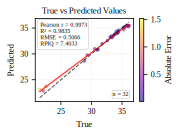

NO.24 [正在训练: Water | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 30
  最优参数: {'learning_rate': 0.07969053481571503, 'max_depth': 8, 'min_child_weight': 7.814046605127344, 'subsample': 0.5118193986403163, 'colsample_bytree': 0.5150173584667858, 'reg_lambda': 0.08794418753130433, 'reg_alpha': 0.008253133183354463, 'gamma': 0.22524337310355277}
  最优验证集 RMSE: 0.3705883324146271
  对应 best_iteration: 130
实验记录已保存: Water-02-XGB-TS-Preprocessing
训练集 R²: 0.9978, 验证集 R²: 0.9912, 测试集 R²: 0.9814



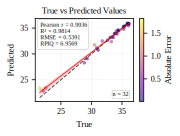

NO.25 [正在训练: FRU | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 61
  最优参数: {'learning_rate': 0.04802658282609856, 'max_depth': 4, 'min_child_weight': 6.103105881887547, 'subsample': 0.6229081242007518, 'colsample_bytree': 0.7086279695551656, 'reg_lambda': 0.0015119457301620528, 'reg_alpha': 0.012232545833665315, 'gamma': 0.6636590685164235}
  最优验证集 RMSE: 2.482309579849243
  对应 best_iteration: 354
实验记录已保存: FRU-02-XGB-TS-Preprocessing
训练集 R²: 0.9863, 验证集 R²: 0.6900, 测试集 R²: 0.5467



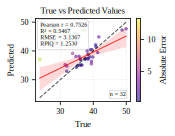

NO.26 [正在训练: FRU | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 80
  最优参数: {'learning_rate': 0.027710587936568803, 'max_depth': 6, 'min_child_weight': 7.332313019445766, 'subsample': 0.5583075415653765, 'colsample_bytree': 0.7073359273412663, 'reg_lambda': 27.970042326255786, 'reg_alpha': 0.0035097680140287863, 'gamma': 4.582762554089349}
  最优验证集 RMSE: 2.451895236968994
  对应 best_iteration: 432
实验记录已保存: FRU-02-XGB-TS-Preprocessing
训练集 R²: 0.8722, 验证集 R²: 0.6975, 测试集 R²: 0.4716



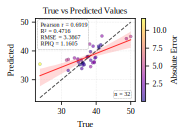

NO.27 [正在训练: FRU | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 73
  最优参数: {'learning_rate': 0.013861691187478467, 'max_depth': 2, 'min_child_weight': 9.788776443536358, 'subsample': 0.519424410012144, 'colsample_bytree': 0.7724074101619421, 'reg_lambda': 0.0019586771283515367, 'reg_alpha': 0.02757474501312347, 'gamma': 2.0331233226480716}
  最优验证集 RMSE: 2.509186029434204
  对应 best_iteration: 533
实验记录已保存: FRU-02-XGB-TS-Preprocessing
训练集 R²: 0.9084, 验证集 R²: 0.6832, 测试集 R²: 0.4057



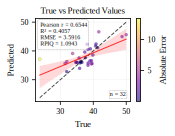

NO.28 [正在训练: FRU | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 98
  最优参数: {'learning_rate': 0.06477043547467072, 'max_depth': 8, 'min_child_weight': 8.203330024985593, 'subsample': 0.5483779511228888, 'colsample_bytree': 0.31789085384549, 'reg_lambda': 0.2720453697406056, 'reg_alpha': 0.010470299188060292, 'gamma': 4.635898349682688}
  最优验证集 RMSE: 2.447387456893921
  对应 best_iteration: 110
实验记录已保存: FRU-02-XGB-TS-Preprocessing
训练集 R²: 0.9357, 验证集 R²: 0.6987, 测试集 R²: 0.4208



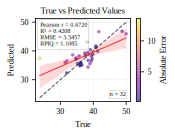

NO.29 [正在训练: FRU | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 52
  最优参数: {'learning_rate': 0.062225690579015745, 'max_depth': 5, 'min_child_weight': 2.297877191382552, 'subsample': 0.5313481896695127, 'colsample_bytree': 0.9522728022679714, 'reg_lambda': 0.0016908877797228504, 'reg_alpha': 0.014795005365435588, 'gamma': 1.9183591953354693}
  最优验证集 RMSE: 2.3031749725341797
  对应 best_iteration: 150
实验记录已保存: FRU-02-XGB-TS-Preprocessing
训练集 R²: 0.9920, 验证集 R²: 0.7331, 测试集 R²: 0.5156



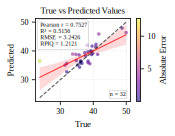

NO.30 [正在训练: FRU | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 82
  最优参数: {'learning_rate': 0.08544753507401773, 'max_depth': 8, 'min_child_weight': 7.430623522584126, 'subsample': 0.5427516221567953, 'colsample_bytree': 0.4247784571069751, 'reg_lambda': 95.16670195998715, 'reg_alpha': 0.08336645219682849, 'gamma': 4.014589923473656}
  最优验证集 RMSE: 2.3500185012817383
  对应 best_iteration: 429
实验记录已保存: FRU-02-XGB-TS-Preprocessing
训练集 R²: 0.9036, 验证集 R²: 0.7222, 测试集 R²: 0.5092



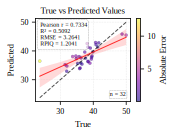

所有模型及预处理对比训练完成！


In [5]:
# 遍历所有 Label 文件
i = 0
for filename in os.listdir(labels_file):
    if filename.endswith(('.csv',)):
        label_path = os.path.join(labels_file, filename)
        label_name = os.path.splitext(filename)[0]

        # 读取并分割数据 (只需做一次)
        try:
            train_set, val_set, test_set = datalodaer.data_split(
                spectra_path,
                label_path,)

            # --- 内部循环：遍历预处理方法 ---
            for prep_name, prep_obj in preprocess_methods.items():
                i += 1
                print(f"NO.{i} [正在训练: {label_name} | 预处理: {prep_name}]========================")

                model_name = series_path
                notes = f"XGBoost + 透射光谱 + {prep_name} 预处理"
                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                # 构造路径名，包含预处理信息
                figure_name = f"Fig_{series_path}-({label_name}; {prep_name})_{timestamp}"

                # 1. 解包数据
                X_train, y_train,_ = train_set
                X_val, y_val,_  = val_set
                X_test, y_test,_  = test_set
                # 2. 应用预处理
                # 注意：必须只在 Train 上 fit，然后 transform 所有数据，防止数据泄露
                X_train_trans = prep_obj.fit_transform(X_train)
                X_val_trans = prep_obj.transform(X_val)
                X_test_trans = prep_obj.transform(X_test)
                # 3. 重新打包
                train_set_trans = (X_train_trans, y_train)
                val_set_trans = (X_val_trans, y_val)
                test_set_trans = (X_test_trans, y_test)
                # 4. 使用 Optuna 寻找最优超参数 (使用处理后的数据)
                best_model, evaluation = model_trainer.tune_xgb_optuna(train_set_trans, val_set_trans)
                # 5. 预测 (使用处理后的数据)
                y_train_pred = best_model.predict(X_train_trans)
                y_val_pred = best_model.predict(X_val_trans)
                y_test_pred = best_model.predict(X_test_trans)
                # 6. 评估
                train_r, train_rmse, train_r2, train_rpiq, train_mae = utils.evaluate_model(y_train, y_train_pred)
                val_r, val_rmse, val_r2, val_rpiq, val_mae = utils.evaluate_model(y_val, y_val_pred)
                test_r, test_rmse, test_r2, test_rpiq, test_mae = utils.evaluate_model(y_test, y_test_pred)
                # 7. 创建当前实验的数据字典
                metrics_data = {
                    'Timestamp': [timestamp, timestamp, timestamp],
                    'Experiment': [label_name, label_name, label_name],
                    'Model': [model_name, model_name, model_name],
                    'Dataset': ['Training', 'Validation', 'Test'],
                    'Pearson_r': [train_r, val_r, test_r],
                    'RMSE': [train_rmse, val_rmse, test_rmse],
                    'R2': [train_r2, val_r2, test_r2],
                    'RPIQ': [train_rpiq, val_rpiq, test_rpiq],
                    'MAE': [train_mae, val_mae, test_mae],
                    'Notes': [notes, notes, notes]
                }
                # 8. 记录实验结果
                logger.log_metrics(metrics_data, model_name, label_name, parameters=evaluation)  # 记录日志
                ploter.correlation_scatter(6.5, 5, test_set[1], y_test_pred, figure_name)
        except Exception as e:
            print(f"执行失败: {filename} - 错误: {str(e)}")

print("所有模型及预处理对比训练完成！")